# Lab 4 — CLIP vs. Traditional Computer Vision

**AI4Mobility** lab notebook

This notebook uses roadway and mobility scenes to compare two ways of thinking about visual AI:

1. **Traditional image classification**, where an image is mapped into one fixed list of labels.
2. **CLIP-style multimodal learning**, where images and text are embedded into a shared semantic space.

The goal is not to win a benchmark. The goal is to build intuition for why multimodal models matter for open-world transportation systems: flooded roadways, work zones, emergency vehicles, scooter riders, nighttime hazards, and long-tail safety scenarios that do not fit neatly into a closed label set.

## Section 1 — Introduction

A traditional computer vision classifier is usually trained to answer a narrow question:

> "Which one of these fixed labels is present in the image?"

That is powerful when the deployment world matches the training label set. But mobility environments are messy. A dashcam may encounter a **flooded roadway**, an improvised **lane blockage**, a **near-crash**, a **scooter rider**, a **nighttime pedestrian hazard**, or a **post-disaster work zone**. These are often not clean ImageNet-style object categories.

CLIP-style models take a different approach. They learn to align images and natural language in a shared embedding space. Instead of only choosing from a fixed label vocabulary, we can ask the model whether an image matches phrases such as:

- "a flooded roadway"
- "a construction work zone"
- "a pedestrian crossing at night"
- "a lane blockage after a crash"
- "a scooter rider in urban traffic"

This is the beginning of **zero-shot understanding**: asking a model about concepts it was not explicitly retrained to classify.

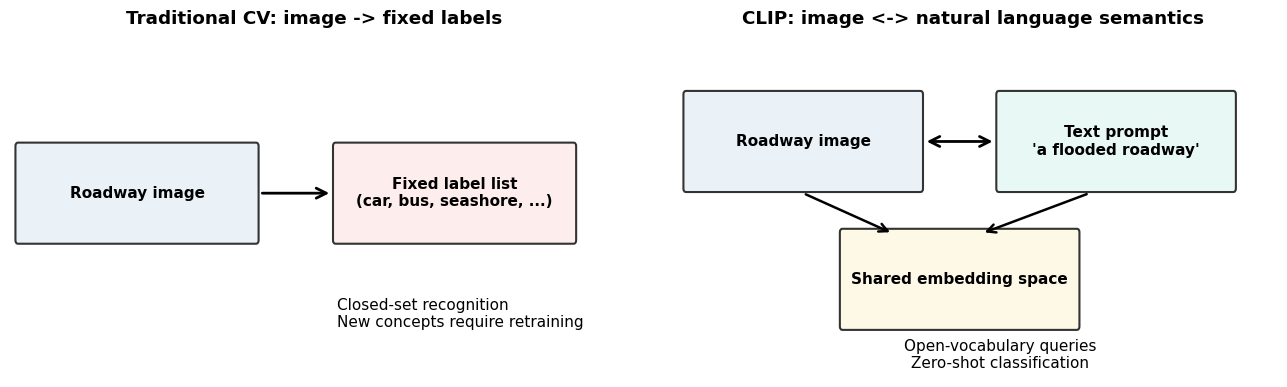

In [16]:
# Conceptual diagram: traditional CV vs. CLIP-style multimodal learning
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

def box(ax, xy, text, color):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), 2.6, 0.8,
        boxstyle="round,pad=0.04,rounding_size=0.03",
        linewidth=1.5,
        edgecolor="#333333",
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + 1.3, y + 0.4, text, ha="center", va="center", weight="bold")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.set_title("Traditional CV: image -> fixed labels", weight="bold")
box(ax, (0.1, 1.2), "Roadway image", "#EAF2F8")
box(ax, (3.6, 1.2), "Fixed label list\n(car, bus, seashore, ...)", "#FDEDEC")
ax.add_patch(FancyArrowPatch((2.75, 1.6), (3.55, 1.6), arrowstyle="->", mutation_scale=18, linewidth=2))
ax.text(3.6, 0.55, "Closed-set recognition\nNew concepts require retraining", ha="left", va="center")
ax.axis("off")
ax.set_xlim(0, 6.7)
ax.set_ylim(0, 3)

ax = axes[1]
ax.set_title("CLIP: image <-> natural language semantics", weight="bold")
box(ax, (0.2, 1.65), "Roadway image", "#EAF2F8")
box(ax, (3.7, 1.65), "Text prompt\n'a flooded roadway'", "#E8F8F5")
box(ax, (1.95, 0.45), "Shared embedding space", "#FEF9E7")
ax.add_patch(FancyArrowPatch((2.85, 2.05), (3.65, 2.05), arrowstyle="<->", mutation_scale=18, linewidth=2))
ax.add_patch(FancyArrowPatch((1.5, 1.6), (2.5, 1.25), arrowstyle="->", mutation_scale=15, linewidth=1.8))
ax.add_patch(FancyArrowPatch((4.7, 1.6), (3.5, 1.25), arrowstyle="->", mutation_scale=15, linewidth=1.8))
ax.text(3.7, 0.05, "Open-vocabulary queries\nZero-shot classification", ha="center", va="bottom")
ax.axis("off")
ax.set_xlim(0, 6.8)
ax.set_ylim(0, 3)

plt.tight_layout()
plt.show()

## Section 2 — Traditional Image Classification Demo

In this section, we use a pretrained **ResNet50** model from `torchvision`. It was trained on **ImageNet**, which contains 1,000 fixed classes such as "sports car", "minibus", "traffic light", "seashore", and many animal/object labels.

That label set is useful, but it is not designed around transportation safety semantics. A flooded roadway may be visually obvious to a person, yet the model is forced to choose among ImageNet labels. This is why traditional classifiers can feel semantically awkward in open-world mobility contexts.

In [17]:
# Setup
# If needed, uncomment and run this install line in a fresh environment:
# !pip install torch torchvision transformers pillow matplotlib scikit-learn ipywidgets requests numpy

from pathlib import Path
from io import BytesIO
import numpy as np
import requests
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

DATA_DIR = Path("data/clip_vs_traditional_cv_demo")
DATA_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


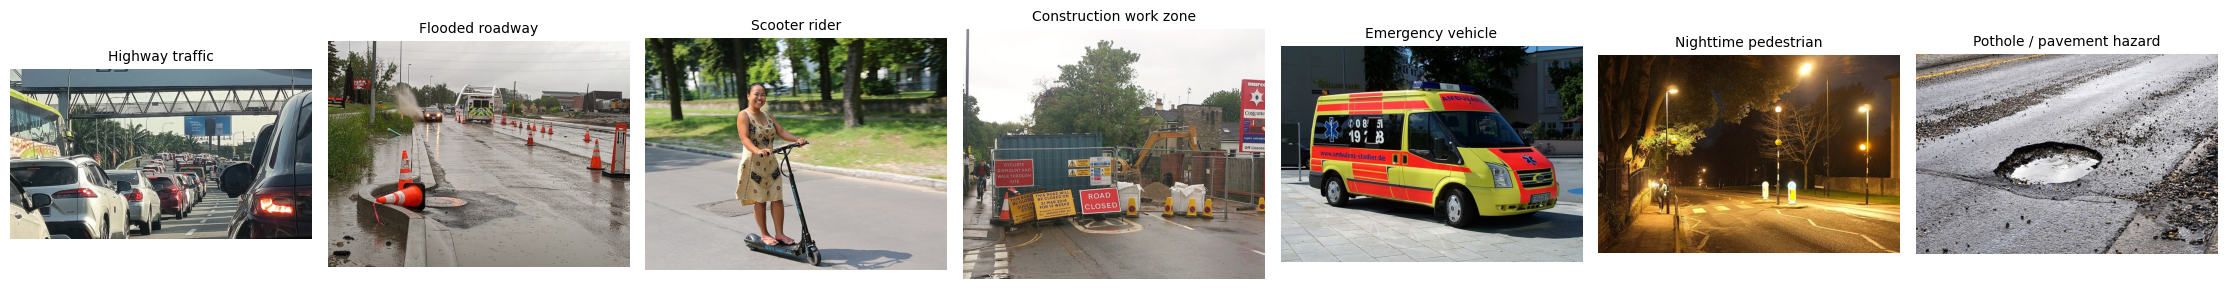

In [18]:
# Mobility image set
# Real-world images come from Wikimedia Commons. The earlier version of this
# notebook hit two problems that silently produced synthetic placeholders:
#   1. Special:FilePath returns an HTML "file not found" page for missing
#      files, which PIL then refused to open.
#   2. Naively constructed thumb URLs use widths Wikimedia does not allow for
#      that specific file (the allowed widths are per-file), returning HTTP 400.
# The fix is to use the documented imageinfo API, which resolves to a working
# thumbnail URL for each file. We also send a descriptive User-Agent (required
# by Wikimedia's UA policy), validate Content-Type, rate-limit, and cache.

import time

# https://meta.wikimedia.org/wiki/User-Agent_policy
WIKIMEDIA_UA = (
    "AIMobilityTeachingNotebook/1.0 "
    "(graduate transportation demo; contact: course instructor)"
)
WIKIMEDIA_API = "https://commons.wikimedia.org/w/api.php"


def resolve_wikimedia_thumb_url(filename: str, target_width: int = 800) -> str:
    """Resolve a working thumbnail URL via the Wikimedia imageinfo API.

    Wikimedia rounds the requested width up to the nearest allowed step for
    the specific file, so we always get back a URL that the upload server
    will actually serve.
    """
    params = {
        "action": "query",
        "prop": "imageinfo",
        "iiprop": "url",
        "iiurlwidth": target_width,
        "titles": "File:" + filename.replace(" ", "_"),
        "format": "json",
    }
    r = requests.get(
        WIKIMEDIA_API, params=params, timeout=20,
        headers={"User-Agent": WIKIMEDIA_UA},
    )
    r.raise_for_status()
    pages = r.json()["query"]["pages"]
    info = next(iter(pages.values())).get("imageinfo")
    if not info:
        raise RuntimeError(f"file not found on Wikimedia Commons: {filename}")
    # Strip tracking params — bare URL is less likely to be throttled.
    return info[0]["thumburl"].split("?", 1)[0]

# Each spec points at a verified Wikimedia Commons file. Concepts are the
# language labels we will later feed to CLIP.
image_specs = [
    {
        "key": "highway_traffic",
        "title": "Highway traffic",
        "concept": "heavy traffic congestion",
        "wikimedia_file": "Malaysia Federal Highway Traffic Jam.jpg",
    },
    {
        "key": "flooded_road",
        "title": "Flooded roadway",
        "concept": "a flooded roadway",
        "wikimedia_file": (
            "A car splashes up water as it drives down a flooded street "
            "in Calgary, Alberta, Canada.jpg"
        ),
    },
    {
        "key": "scooter_rider",
        "title": "Scooter rider",
        "concept": "a scooter rider",
        "wikimedia_file": "Female rider on Egret One eScooter.jpg",
    },
    {
        "key": "work_zone",
        "title": "Construction work zone",
        "concept": "a construction work zone",
        "wikimedia_file": (
            "Roadworks, Hampton Road - geograph.org.uk - 3993383.jpg"
        ),
    },
    {
        "key": "emergency_vehicle",
        "title": "Emergency vehicle",
        "concept": "an emergency vehicle",
        "wikimedia_file": "Krankentransportwagen in Passau.JPG",
    },
    {
        "key": "night_pedestrian",
        "title": "Nighttime pedestrian",
        "concept": "a pedestrian crossing at night",
        "wikimedia_file": (
            "Pedestrian crossing at night, Redland - geograph.org.uk - "
            "6034970.jpg"
        ),
    },
]

# Include the local course pothole image if present.
local_pothole = Path("data/pothole.jpg")
if local_pothole.exists():
    image_specs.append({
        "key": "pothole",
        "title": "Pothole / pavement hazard",
        "concept": "a roadway surface hazard",
        "local_path": str(local_pothole),
    })


def synthetic_mobility_image(title, concept, size=(640, 420)):
    """Last-resort placeholder for offline runs. Real images are preferred."""
    img = Image.new("RGB", size, "#dfeaf2")
    draw = ImageDraw.Draw(img)
    w, h = size
    draw.rectangle([0, int(h*0.55), w, h], fill="#565c61")
    draw.polygon(
        [(0, h), (w*0.38, h*0.55), (w*0.62, h*0.55), (w, h)], fill="#42484d",
    )
    for y in np.linspace(h*0.62, h*0.94, 5):
        draw.rectangle([w*0.49, y, w*0.51, y+18], fill="#f7f1a0")
    draw.rectangle([12, 12, w-12, 72], fill="#ffffff")
    draw.text((28, 28), f"{title} (placeholder)", fill="#111111")
    return img


def _download_image(url: str, out_path: Path, timeout: int = 25) -> Image.Image:
    """Download `url` into `out_path` and return the PIL image.

    Validates Content-Type so we never cache an error page as a .jpg.
    """
    response = requests.get(
        url, timeout=timeout, headers={"User-Agent": WIKIMEDIA_UA},
    )
    response.raise_for_status()
    ctype = response.headers.get("Content-Type", "")
    if not ctype.startswith("image/"):
        raise RuntimeError(
            f"expected image/*, got {ctype!r} (likely a not-found HTML page)"
        )
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img.thumbnail((900, 650))
    img.save(out_path, quality=92)
    return img


def load_or_create_image(spec, request_delay: float = 0.0):
    if spec.get("local_path") and Path(spec["local_path"]).exists():
        return Image.open(spec["local_path"]).convert("RGB")

    out = DATA_DIR / f"{spec['key']}.jpg"
    if out.exists():
        try:
            return Image.open(out).convert("RGB")
        except Exception:
            out.unlink(missing_ok=True)  # corrupt cache — refetch

    if spec.get("wikimedia_file"):
        try:
            if request_delay:
                time.sleep(request_delay)
            url = resolve_wikimedia_thumb_url(spec["wikimedia_file"])
            time.sleep(request_delay)  # second pause before fetching the image
            return _download_image(url, out)
        except Exception as exc:
            print(f"Download failed for {spec['title']}: {exc}")

    print(f"Using synthetic placeholder for {spec['title']}")
    img = synthetic_mobility_image(spec["title"], spec["concept"])
    img.save(out, quality=92)
    return img


# Rate-limit between requests to stay within Wikimedia's robot policy.
# The delay applies once for the API call and once for the image fetch, so
# the total per-spec pause is ~2x request_delay.
images = []
for i, spec in enumerate(image_specs):
    img = load_or_create_image(spec, request_delay=1.5 if i > 0 else 0.0)
    images.append({**spec, "image": img})

fig, axes = plt.subplots(1, len(images), figsize=(3.2 * len(images), 3.2))
if len(images) == 1:
    axes = [axes]
for ax, item in zip(axes, images):
    ax.imshow(item["image"])
    ax.set_title(item["title"], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Load pretrained ResNet50 for traditional ImageNet classification
from torchvision.models import resnet50, ResNet50_Weights

resnet_weights = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=resnet_weights).to(device).eval()
resnet_preprocess = resnet_weights.transforms()
imagenet_categories = resnet_weights.meta["categories"]

@torch.no_grad()
def resnet_topk(pil_image, k=5):
    x = resnet_preprocess(pil_image).unsqueeze(0).to(device)
    logits = resnet(x)
    probs = logits.softmax(dim=1)[0]
    top_probs, top_idx = probs.topk(k)
    return [(imagenet_categories[i], float(p)) for p, i in zip(top_probs.cpu(), top_idx.cpu())]

for item in images:
    item["resnet_top5"] = resnet_topk(item["image"], k=5)

print("Example ImageNet categories available to ResNet:")
print(", ".join(imagenet_categories[:20]) + ", ...")

Example ImageNet categories available to ResNet:
tench, goldfish, great white shark, tiger shark, hammerhead, electric ray, stingray, cock, hen, ostrich, brambling, goldfinch, house finch, junco, indigo bunting, robin, bulbul, jay, magpie, chickadee, ...


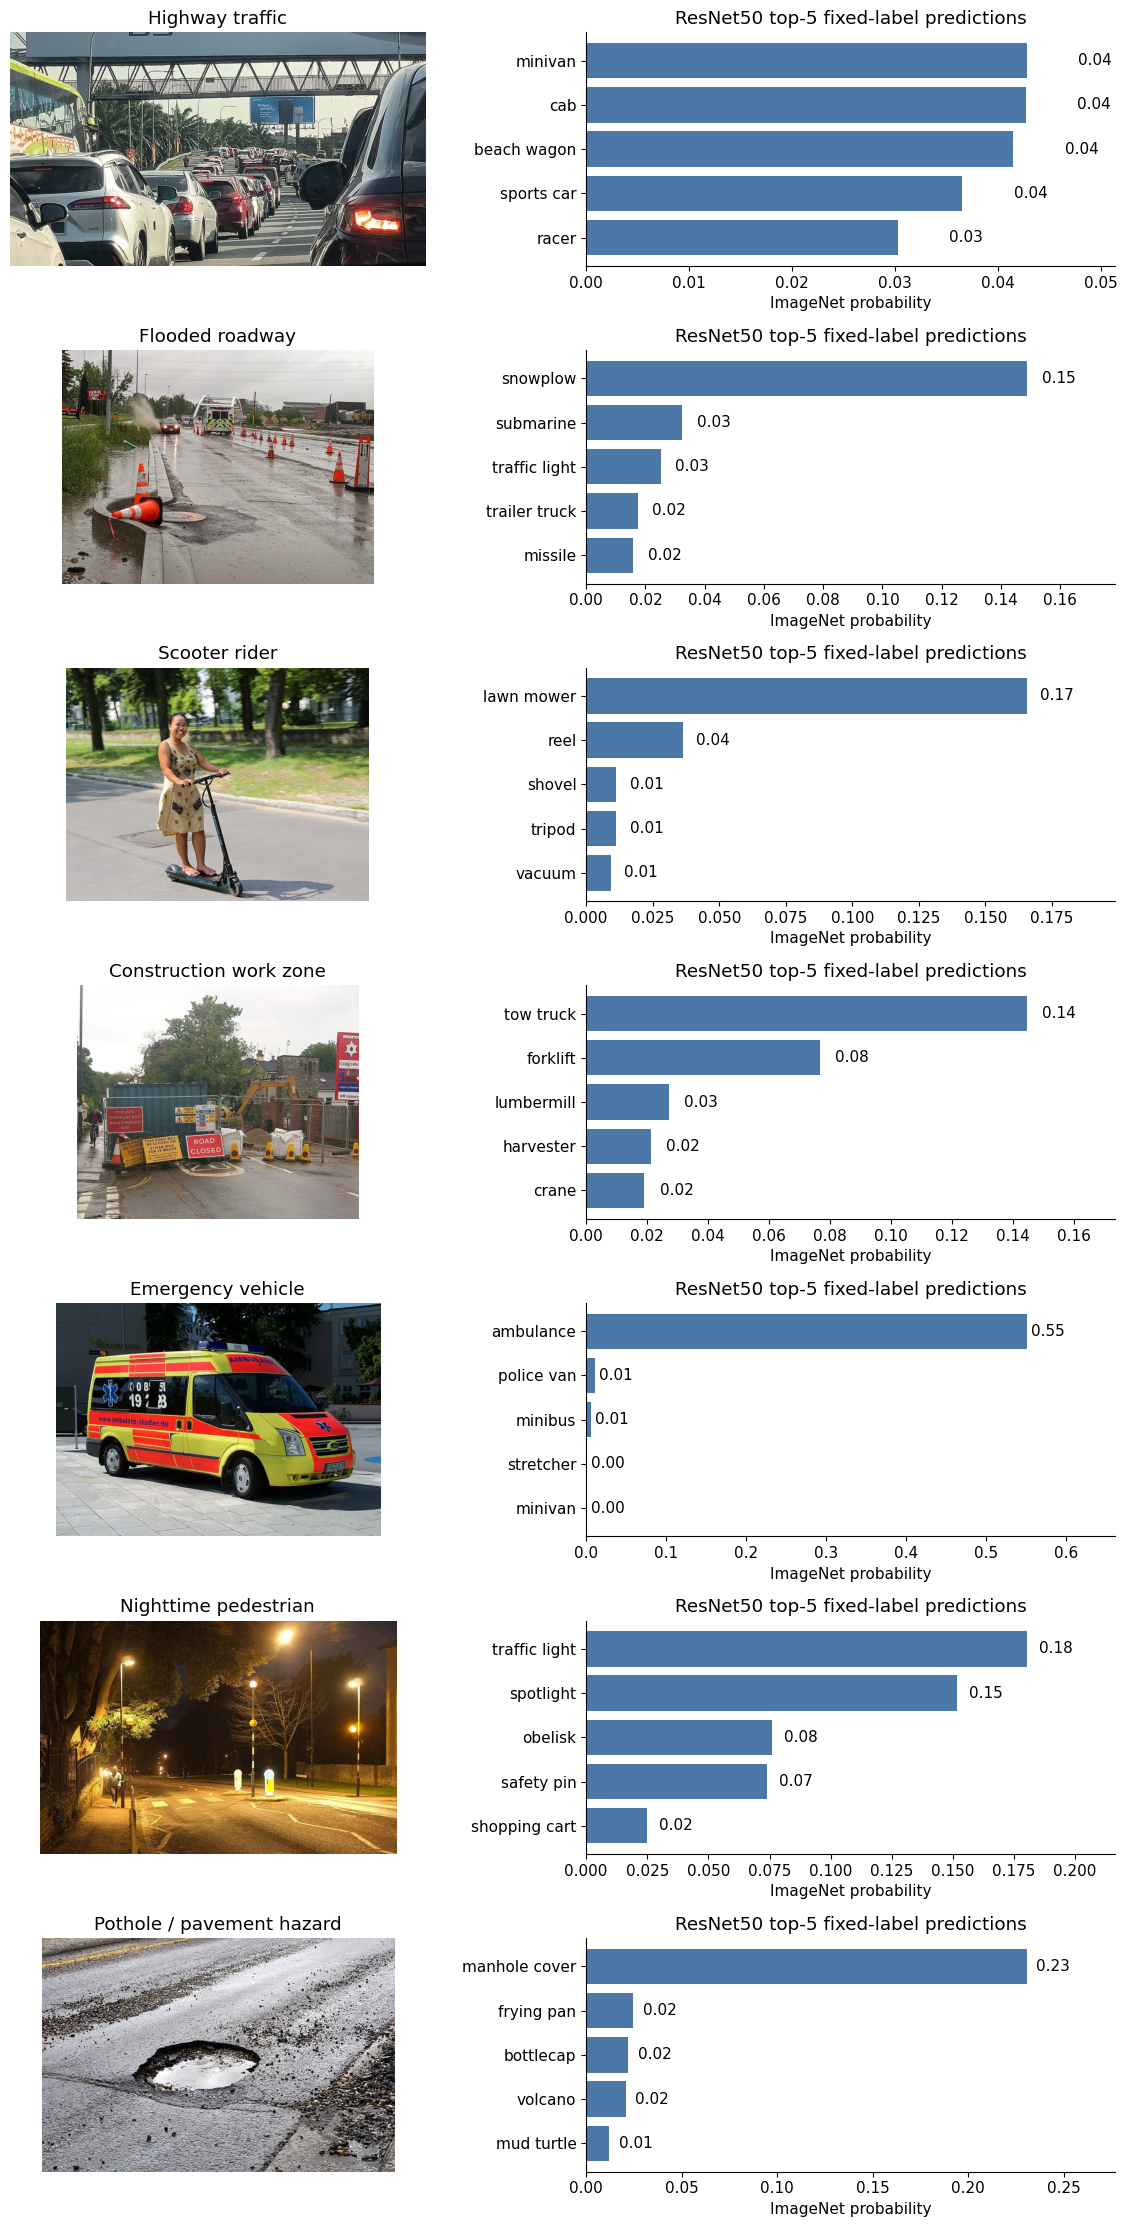

In [20]:
# Visualize traditional classifier outputs

def plot_resnet_results(items):
    n = len(items)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.2 * n))
    if n == 1:
        axes = np.array([axes])
    for row, item in enumerate(items):
        ax_img, ax_bar = axes[row]
        ax_img.imshow(item["image"])
        ax_img.set_title(item["title"])
        ax_img.axis("off")

        labels = [x[0] for x in item["resnet_top5"]][::-1]
        scores = [x[1] for x in item["resnet_top5"]][::-1]
        ax_bar.barh(labels, scores, color="#4C78A8")
        ax_bar.set_xlim(0, max(scores) * 1.2 if scores else 1)
        ax_bar.set_xlabel("ImageNet probability")
        ax_bar.set_title("ResNet50 top-5 fixed-label predictions")
        for i, score in enumerate(scores):
            ax_bar.text(score + 0.005, i, f"{score:.2f}", va="center")
    plt.tight_layout()
    plt.show()

plot_resnet_results(images)

### What should students notice?

The model may recognize some objects, such as a vehicle or traffic light, but it cannot produce labels like "unsafe flooded road," "lane blockage," or "nighttime pedestrian hazard" unless those labels exist in its fixed output vocabulary.

That is the central limitation of closed-set classification:

> The model can only choose among labels it was trained to output.

For transportation AI, the hardest cases are often **long-tail situations**: rare hazards, unusual combinations, temporary infrastructure, weather disruption, and ambiguous safety-critical scenes.

## Section 3 — CLIP Zero-Shot Demo

This section includes a side-by-side prediction comparison: the same roadway image is interpreted first through fixed ImageNet labels and then through mobility-specific language prompts.

Now we use a CLIP model. CLIP compares an image against natural-language prompts. We do not add a new classifier head and we do not retrain the model for these exact mobility labels.

Instead, we write prompts such as "a flooded roadway" or "a scooter rider" and ask:

> Which text description is closest to this image in the shared embedding space?

That is the operational meaning of **zero-shot classification** in this demo.

In [21]:
# Load CLIP from HuggingFace Transformers
from transformers import CLIPModel, CLIPProcessor

clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

prompts = [
    "a flooded roadway",
    "a construction work zone",
    "a pedestrian crossing at night",
    "an emergency vehicle",
    "heavy traffic congestion",
    "a scooter rider",
    "a lane blockage",
    "a safe roadway scene",
    "a roadway surface hazard",
    "a near-crash traffic scene",
]

@torch.no_grad()
def clip_probabilities(pil_images, text_prompts):
    inputs = clip_processor(
        text=text_prompts,
        images=pil_images,
        return_tensors="pt",
        padding=True,
    ).to(device)
    outputs = clip_model(**inputs)
    logits = outputs.logits_per_image
    probs = logits.softmax(dim=1).cpu().numpy()
    return probs, logits.cpu().numpy()

clip_probs, clip_logits = clip_probabilities([item["image"] for item in images], prompts)
for item, probs in zip(images, clip_probs):
    order = probs.argsort()[::-1]
    item["clip_ranking"] = [(prompts[i], float(probs[i])) for i in order]
    item["clip_best"] = item["clip_ranking"][0]

for item in images:
    print(f"{item['title']}: {item['clip_best'][0]} ({item['clip_best'][1]:.2f})")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 55860.43it/s]


Highway traffic: heavy traffic congestion (0.72)
Flooded roadway: a flooded roadway (0.54)
Scooter rider: a scooter rider (1.00)
Construction work zone: a lane blockage (0.65)
Emergency vehicle: an emergency vehicle (1.00)
Nighttime pedestrian: a pedestrian crossing at night (1.00)
Pothole / pavement hazard: a roadway surface hazard (0.94)


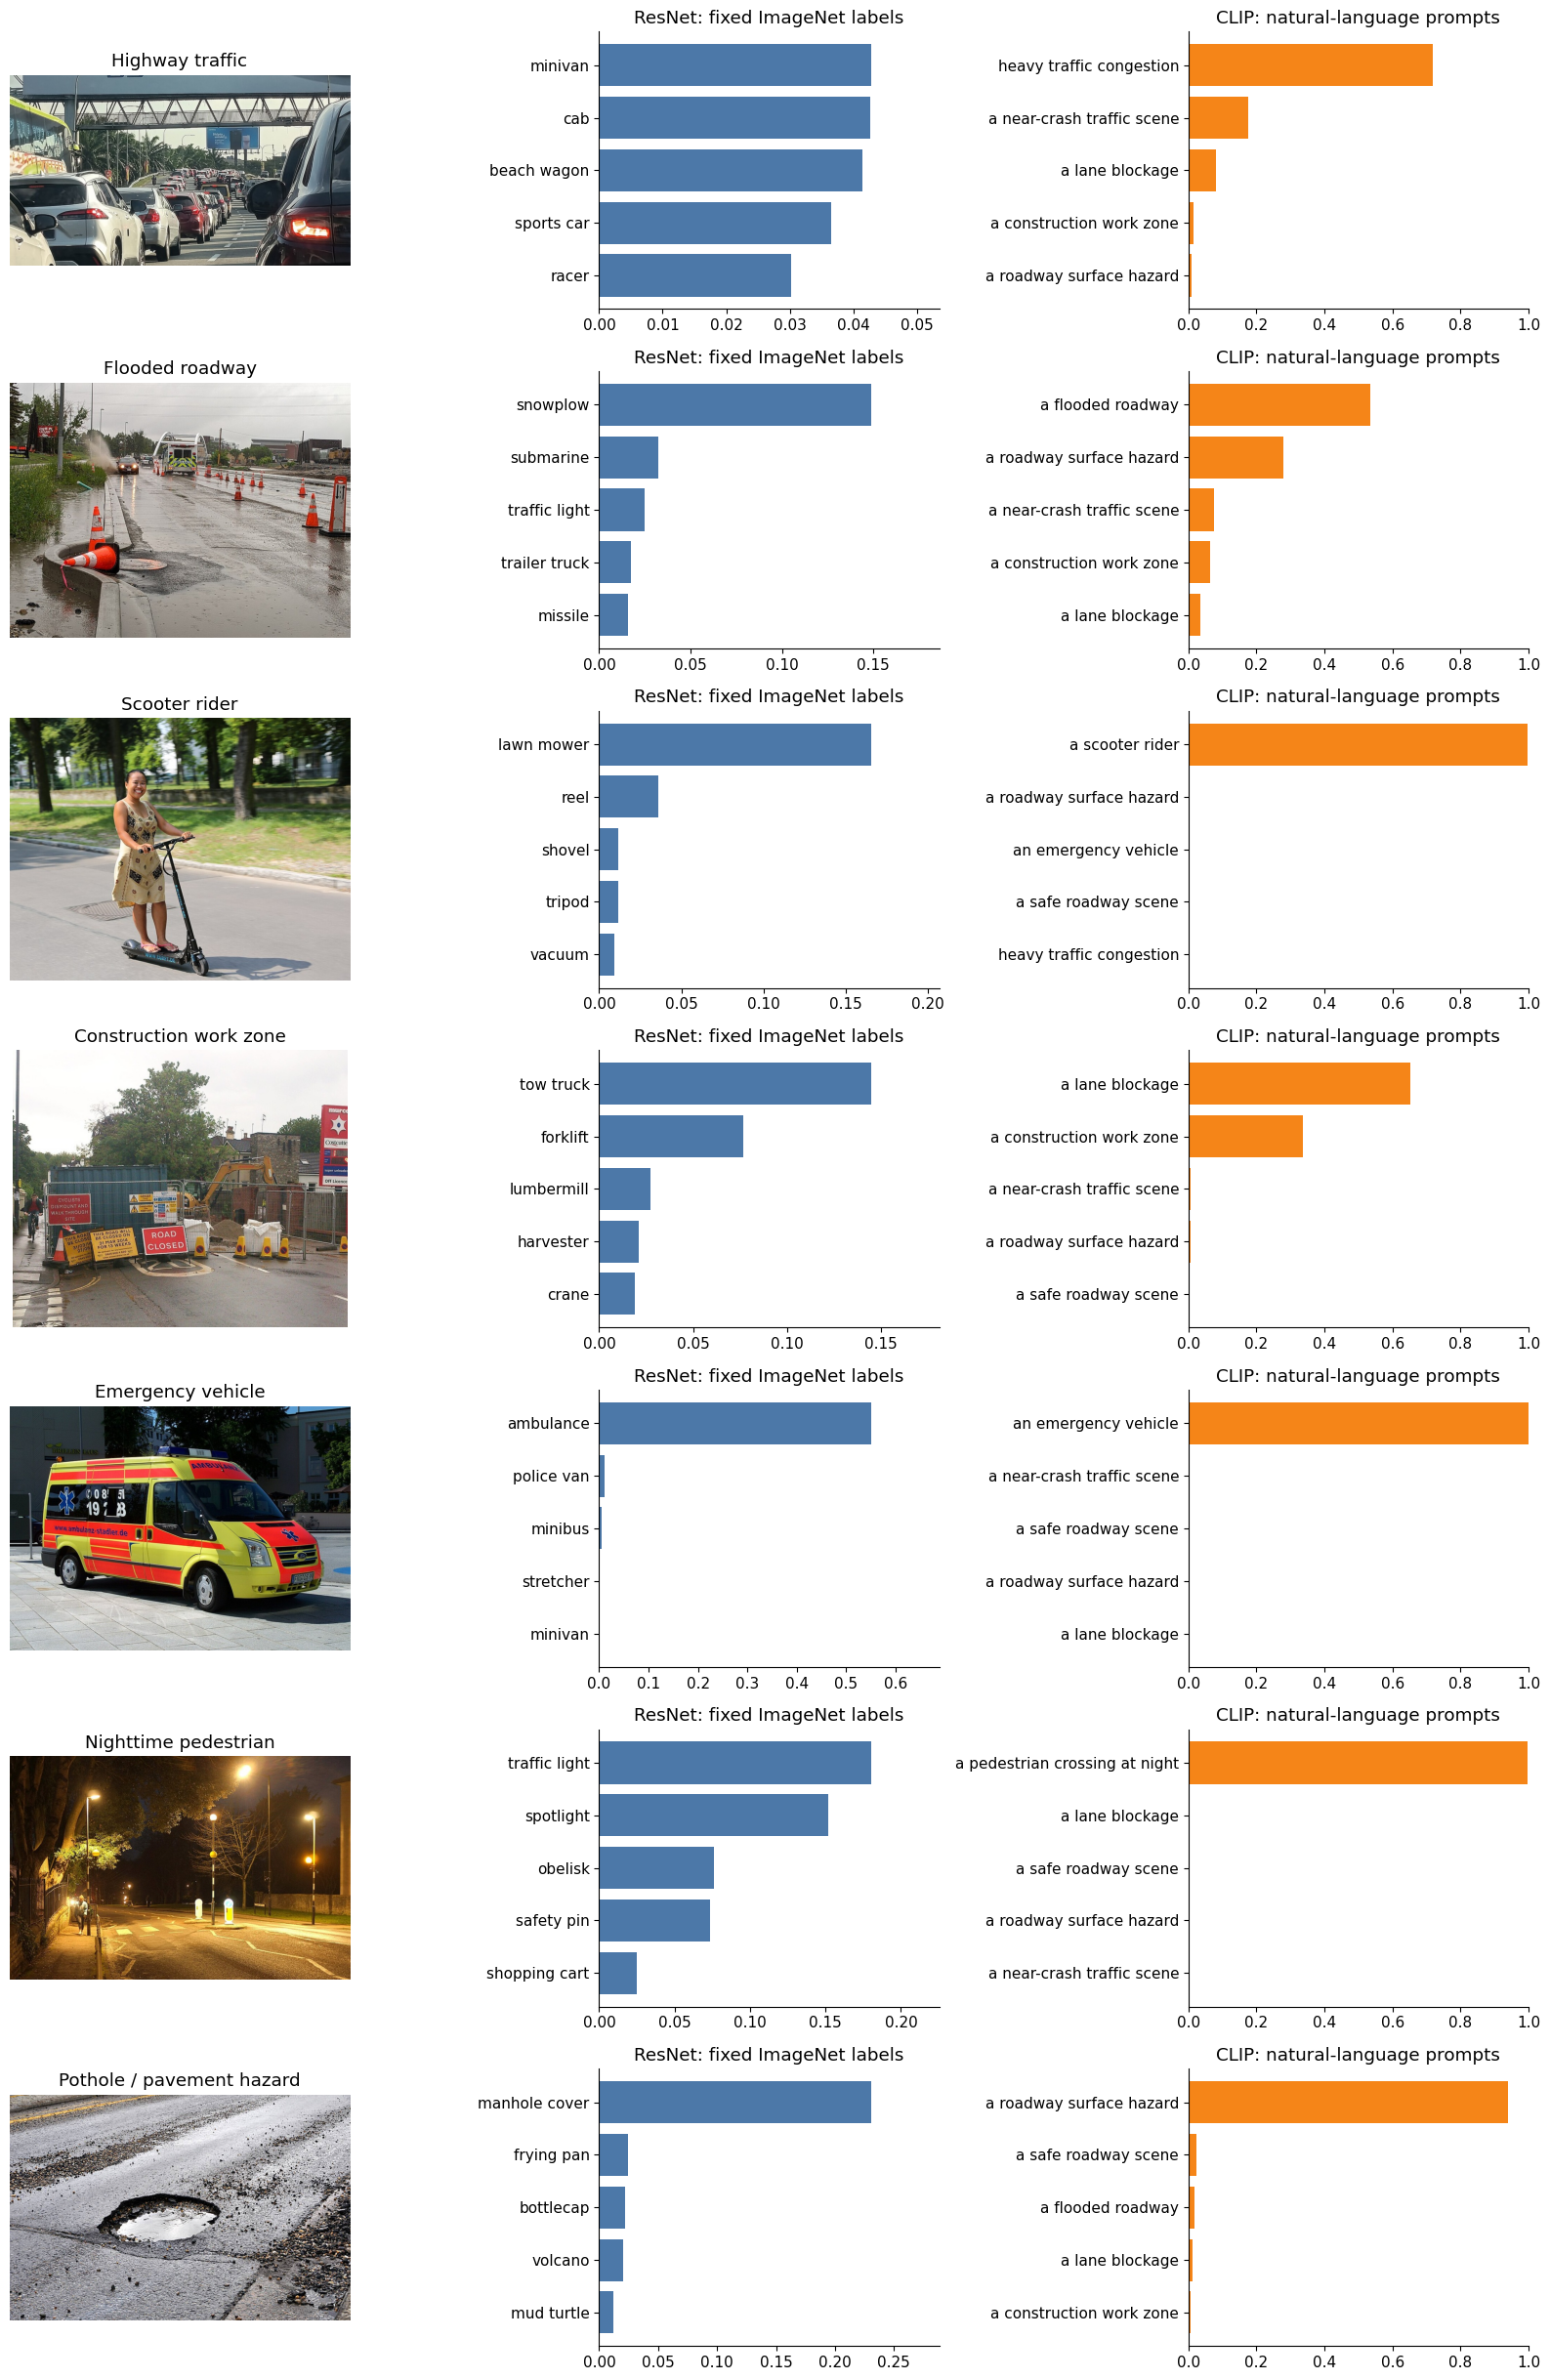

In [22]:
# Side-by-side comparison: traditional fixed labels vs. CLIP prompts

def plot_comparison(items, prompts_to_show=5):
    n = len(items)
    fig, axes = plt.subplots(n, 3, figsize=(16, 3.5 * n))
    if n == 1:
        axes = np.array([axes])
    for row, item in enumerate(items):
        ax_img, ax_resnet, ax_clip = axes[row]
        ax_img.imshow(item["image"])
        ax_img.set_title(item["title"])
        ax_img.axis("off")

        res_labels = [x[0] for x in item["resnet_top5"]][::-1]
        res_scores = [x[1] for x in item["resnet_top5"]][::-1]
        ax_resnet.barh(res_labels, res_scores, color="#4C78A8")
        ax_resnet.set_title("ResNet: fixed ImageNet labels")
        ax_resnet.set_xlim(0, max(res_scores) * 1.25 if res_scores else 1)

        clip_top = item["clip_ranking"][:prompts_to_show]
        clip_labels = [x[0] for x in clip_top][::-1]
        clip_scores = [x[1] for x in clip_top][::-1]
        ax_clip.barh(clip_labels, clip_scores, color="#F58518")
        ax_clip.set_title("CLIP: natural-language prompts")
        ax_clip.set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

plot_comparison(images)

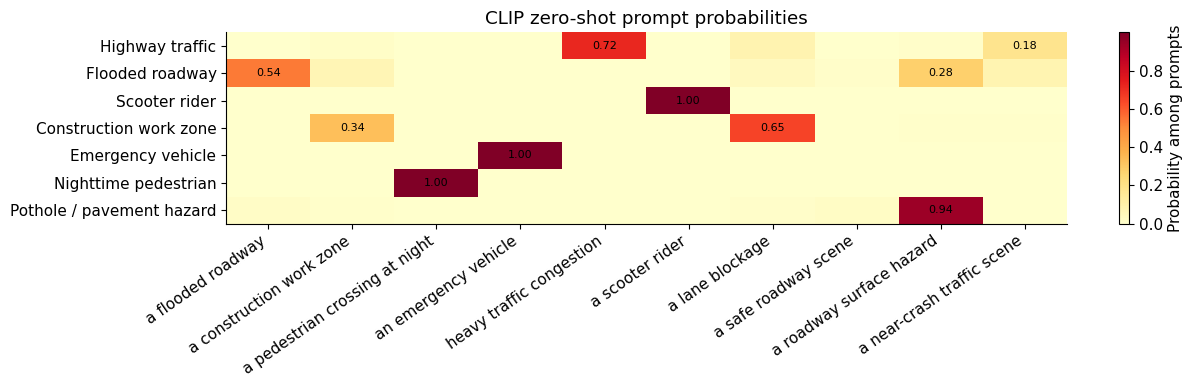

In [23]:
# Cosine-similarity-style heatmap across all image/prompt pairs
# CLIP logits are scaled similarities. For teaching, row-normalized probabilities are easier to read.

fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(images))))
im = ax.imshow(clip_probs, cmap="YlOrRd", aspect="auto", vmin=0, vmax=max(0.25, clip_probs.max()))
ax.set_xticks(range(len(prompts)))
ax.set_xticklabels(prompts, rotation=35, ha="right")
ax.set_yticks(range(len(images)))
ax.set_yticklabels([item["title"] for item in images])
ax.set_title("CLIP zero-shot prompt probabilities")
for i in range(clip_probs.shape[0]):
    for j in range(clip_probs.shape[1]):
        if clip_probs[i, j] > 0.08:
            ax.text(j, i, f"{clip_probs[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Probability among prompts")
plt.tight_layout()
plt.show()

### Zero-shot interpretation

The important point is not that CLIP is always correct. The important point is that the **label space has moved into language**.

A transportation researcher can test prompts like "post-hurricane roadway," "temporary lane closure," or "micromobility conflict" without collecting a new labeled dataset and retraining a classifier from scratch. That makes CLIP-style models attractive for exploratory analysis and long-tail mobility scenarios.

## Section 4 — Visualizing Embedding Similarity

CLIP embeds both images and text into vectors. Once both are vectors, we can compare them using **cosine similarity**:

$$
\text{cosine similarity}(x, y) = \frac{x \cdot y}{\lVert x \rVert\,\lVert y \rVert}
$$

Intuition: two vectors pointing in a similar direction are semantically close. In CLIP, a flooded-road image should point closer to "a flooded roadway" than to "a scooter rider."

In [24]:
# Compute normalized CLIP embeddings for images and text.
# In transformers >= 5 the helpers return a BaseModelOutputWithPooling whose
# `.pooler_output` holds the projected features; older releases returned a
# plain tensor. We handle both so the notebook works across versions.

def _as_tensor(features):
    if isinstance(features, torch.Tensor):
        return features
    if hasattr(features, "pooler_output"):
        return features.pooler_output
    raise TypeError(f"unexpected CLIP feature type: {type(features).__name__}")

@torch.no_grad()
def get_clip_embeddings(pil_images, text_prompts):
    image_inputs = clip_processor(images=pil_images, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=text_prompts, return_tensors="pt", padding=True).to(device)

    image_features = _as_tensor(clip_model.get_image_features(**image_inputs))
    text_features = _as_tensor(clip_model.get_text_features(**text_inputs))

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return image_features.cpu().numpy(), text_features.cpu().numpy()

image_embeddings, text_embeddings = get_clip_embeddings([item["image"] for item in images], prompts)
similarity = image_embeddings @ text_embeddings.T
print("Embedding matrix shape:", image_embeddings.shape, text_embeddings.shape)

Embedding matrix shape: (7, 512) (10, 512)


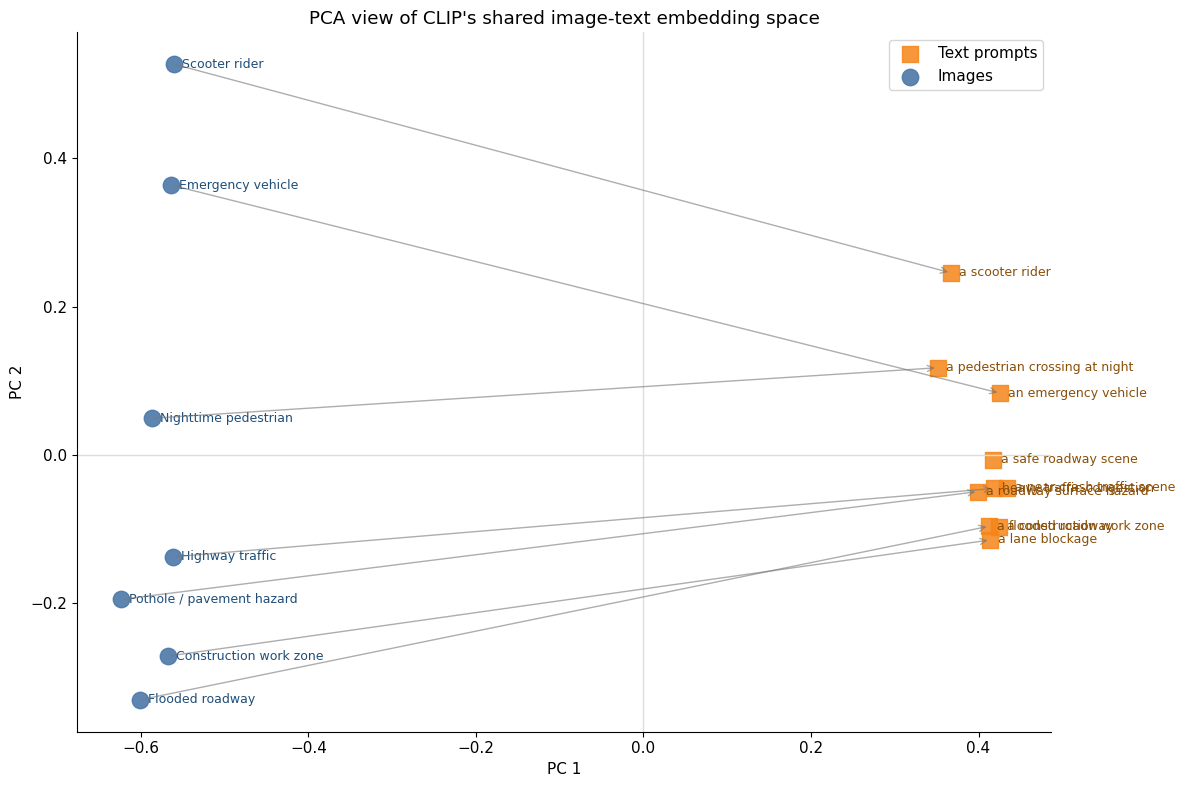

In [25]:
# PCA projection of image and text embeddings into 2D
from sklearn.decomposition import PCA

all_embeddings = np.vstack([image_embeddings, text_embeddings])
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(all_embeddings)
img_xy = xy[:len(images)]
txt_xy = xy[len(images):]

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(txt_xy[:, 0], txt_xy[:, 1], s=120, marker="s", color="#F58518", label="Text prompts", alpha=0.85)
ax.scatter(img_xy[:, 0], img_xy[:, 1], s=140, marker="o", color="#4C78A8", label="Images", alpha=0.9)

for i, item in enumerate(images):
    ax.text(img_xy[i, 0], img_xy[i, 1], "  " + item["title"], va="center", fontsize=9, color="#1f4e79")
    best_prompt_idx = prompts.index(item["clip_best"][0])
    ax.annotate(
        "",
        xy=(txt_xy[best_prompt_idx, 0], txt_xy[best_prompt_idx, 1]),
        xytext=(img_xy[i, 0], img_xy[i, 1]),
        arrowprops=dict(arrowstyle="->", color="#777777", lw=1, alpha=0.6),
    )

for j, prompt in enumerate(prompts):
    ax.text(txt_xy[j, 0], txt_xy[j, 1], "  " + prompt, va="center", fontsize=9, color="#8a4f08")

ax.axhline(0, color="#dddddd", lw=1)
ax.axvline(0, color="#dddddd", lw=1)
ax.set_title("PCA view of CLIP's shared image-text embedding space")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

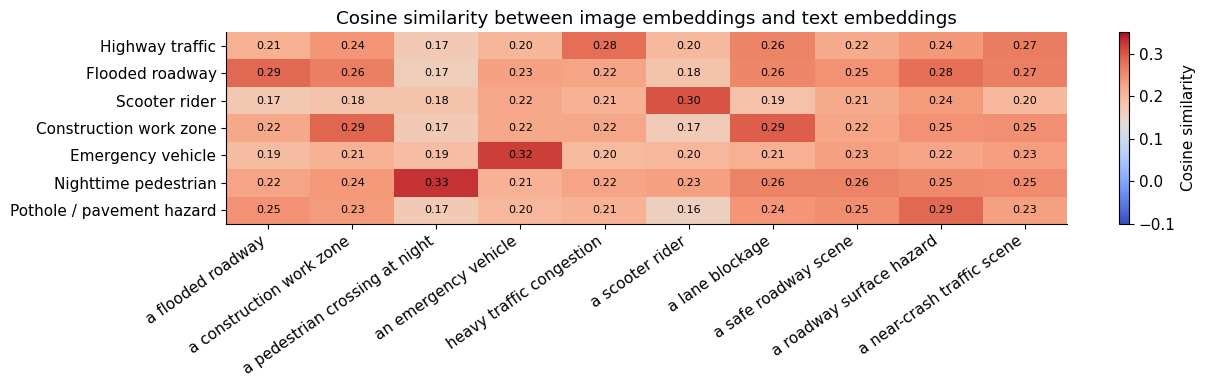

In [26]:
# Similarity heatmap using normalized image and text embeddings
fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(images))))
im = ax.imshow(similarity, cmap="coolwarm", aspect="auto", vmin=-0.1, vmax=0.35)
ax.set_xticks(range(len(prompts)))
ax.set_xticklabels(prompts, rotation=35, ha="right")
ax.set_yticks(range(len(images)))
ax.set_yticklabels([item["title"] for item in images])
ax.set_title("Cosine similarity between image embeddings and text embeddings")
for i in range(similarity.shape[0]):
    for j in range(similarity.shape[1]):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Cosine similarity")
plt.tight_layout()
plt.show()

### Reading the embedding plot

This 2D plot is a compressed view of a much higher-dimensional space, so it is only an intuition aid. The core idea is still useful:

- Image embeddings and text embeddings live in the same coordinate system.
- Cosine similarity measures semantic alignment.
- A prompt can act like a flexible query into visual data.

For mobility AI, this means text can become an interface for searching and interpreting roadway scenes.

## Section 5 — Why Contrastive Learning Matters

A traditional supervised classifier learns something like:

$$
\text{image} \rightarrow \text{one fixed class label}
$$

A captioning model learns something like:

$$
\text{image} \rightarrow \text{exact sentence}
$$

CLIP-style contrastive learning uses a different objective. During training, the model sees many image-text pairs. It learns to make matching pairs close and nonmatching pairs farther apart:

$$
\text{match}(I, T^+) \uparrow \quad \text{and} \quad \text{match}(I, T^-) \downarrow
$$

where $I$ is an image, $T^+$ is a matching text description, and $T^-$ is a nonmatching text description.

Consider a mobility image of a flooded intersection. Several descriptions may be reasonable:

- "a flooded road"
- "standing water hazard"
- "roadway inundation"
- "post-storm street flooding"

A contrastive model does not need one exact wording. It learns a semantic neighborhood where visually and linguistically related ideas can be close together. That is why CLIP can often handle prompt variation better than a fixed-label classifier.

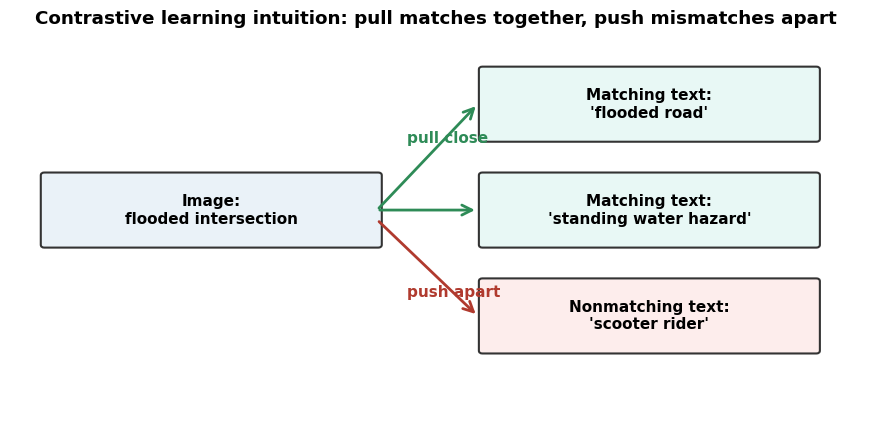

In [27]:
# Mini contrastive-learning diagram with a mobility example
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Contrastive learning intuition: pull matches together, push mismatches apart", weight="bold")
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.04,rounding_size=0.03", linewidth=1.5, edgecolor="#333333")

def add_text_box(x, y, text, color):
    patch = FancyBboxPatch((x, y), 2.8, 0.7, facecolor=color, **box_style)
    ax.add_patch(patch)
    ax.text(x + 1.4, y + 0.35, text, ha="center", va="center", weight="bold")

add_text_box(0.3, 2.0, "Image:\nflooded intersection", "#EAF2F8")
add_text_box(4.0, 3.1, "Matching text:\n'flooded road'", "#E8F8F5")
add_text_box(4.0, 2.0, "Matching text:\n'standing water hazard'", "#E8F8F5")
add_text_box(4.0, 0.9, "Nonmatching text:\n'scooter rider'", "#FDEDEC")

ax.add_patch(FancyArrowPatch((3.1, 2.35), (3.95, 3.45), arrowstyle="->", mutation_scale=18, linewidth=2, color="#2E8B57"))
ax.add_patch(FancyArrowPatch((3.1, 2.35), (3.95, 2.35), arrowstyle="->", mutation_scale=18, linewidth=2, color="#2E8B57"))
ax.add_patch(FancyArrowPatch((3.1, 2.25), (3.95, 1.25), arrowstyle="->", mutation_scale=18, linewidth=2, color="#B03A2E"))
ax.text(3.35, 3.05, "pull close", color="#2E8B57", weight="bold")
ax.text(3.35, 1.45, "push apart", color="#B03A2E", weight="bold")
ax.set_xlim(0, 7.2)
ax.set_ylim(0.2, 4.2)
plt.show()

## Section 6 — Interactive Prompt Engineering

This interactive cell lets you query roadway images with your own language. Try prompts such as:

- unsafe merge
- near crash
- damaged traffic signal
- post-hurricane roadway
- blocked bike lane
- pedestrian conflict at night

Prompt engineering is not magic. Small wording changes can matter. That sensitivity is part of what students should observe.

ipywidgets is not installed in this environment.
Install it with: pip install ipywidgets
Running a static prompt-ranking demo instead.


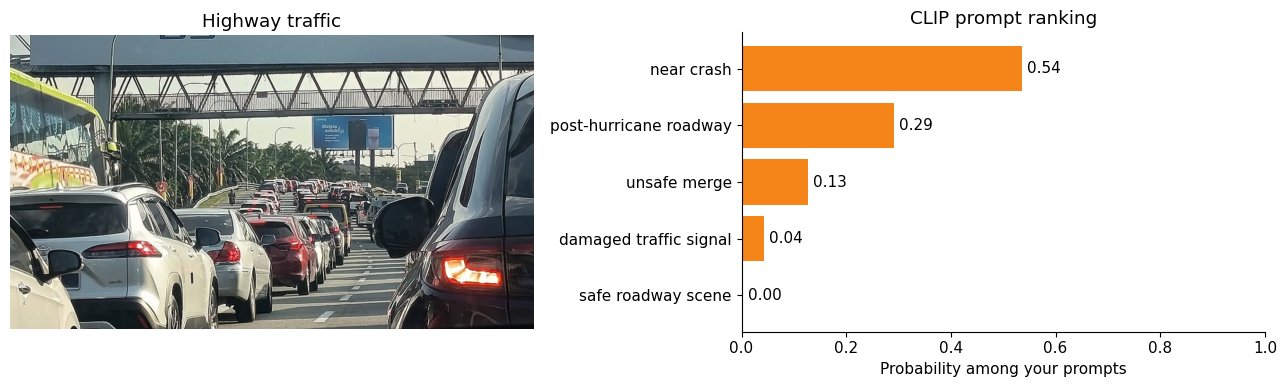

Best match: near crash | probability=0.536 | raw similarity logit=25.80


In [28]:
# Interactive prompt engineering demo
# If ipywidgets is installed, this cell creates an interactive prompt tester.
# If not, it falls back to a static demo so the notebook still runs end-to-end.

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not installed in this environment.")
    print("Install it with: pip install ipywidgets")
    print("Running a static prompt-ranking demo instead.")


def plot_prompt_ranking(pil_img, title, custom_prompts):
    probs, logits = clip_probabilities([pil_img], custom_prompts)
    probs = probs[0]
    raw_sims = logits[0]
    order = probs.argsort()[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].imshow(pil_img)
    axes[0].set_title(title)
    axes[0].axis("off")

    labels = [custom_prompts[i] for i in order][::-1]
    scores = [probs[i] for i in order][::-1]
    axes[1].barh(labels, scores, color="#F58518")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability among your prompts")
    axes[1].set_title("CLIP prompt ranking")
    for y, score in enumerate(scores):
        axes[1].text(score + 0.01, y, f"{score:.2f}", va="center")
    plt.tight_layout()
    plt.show()

    best = order[0]
    print(f"Best match: {custom_prompts[best]} | probability={probs[best]:.3f} | raw similarity logit={raw_sims[best]:.2f}")


if WIDGETS_AVAILABLE:
    image_dropdown = widgets.Dropdown(
        options=[(item["title"], i) for i, item in enumerate(images)],
        value=0,
        description="Image:",
        layout=widgets.Layout(width="420px"),
    )

    prompt_text = widgets.Textarea(
        value="a flooded roadway\na lane blockage\na near-crash traffic scene\na safe roadway scene",
        description="Prompts:",
        layout=widgets.Layout(width="650px", height="120px"),
    )

    upload = widgets.FileUpload(accept="image/*", multiple=False, description="Upload image")
    run_button = widgets.Button(description="Compare prompts", button_style="primary")
    output = widgets.Output()

    def selected_image():
        if upload.value:
            uploaded = next(iter(upload.value.values())) if isinstance(upload.value, dict) else upload.value[0]
            content = uploaded["content"] if isinstance(uploaded, dict) else uploaded.content
            return Image.open(BytesIO(content)).convert("RGB"), "Uploaded image"
        idx = image_dropdown.value
        return images[idx]["image"], images[idx]["title"]

    def run_interactive(_=None):
        with output:
            clear_output(wait=True)
            pil_img, title = selected_image()
            custom_prompts = [p.strip() for p in prompt_text.value.splitlines() if p.strip()]
            if not custom_prompts:
                print("Type at least one prompt.")
                return
            plot_prompt_ranking(pil_img, title, custom_prompts)

    run_button.on_click(run_interactive)
    display(widgets.VBox([image_dropdown, upload, prompt_text, run_button, output]))
    run_interactive()
else:
    static_prompts = [
        "unsafe merge",
        "near crash",
        "damaged traffic signal",
        "post-hurricane roadway",
        "safe roadway scene",
    ]
    plot_prompt_ranking(images[0]["image"], images[0]["title"], static_prompts)

## Section 7 — Failure Cases of CLIP

CLIP is useful, but it is not a transportation reasoning engine.

It learns statistical alignment between images and language. It does not truly understand traffic causality, vehicle dynamics, right-of-way rules, crash physics, infrastructure design standards, or whether a situation is legally unsafe.

Important limitations:

- **Ambiguity:** A nighttime scene may be matched to "pedestrian hazard" because of lighting or crosswalk cues, even if no pedestrian is visible.
- **Prompt sensitivity:** "work zone," "construction zone," and "temporary lane closure" may produce different rankings.
- **Bias and dataset artifacts:** The model may associate certain contexts with concepts because of web-scale training correlations.
- **No causal reasoning:** CLIP may identify a scene as a "near crash" from visual similarity, but it does not simulate trajectories or infer counterfactual risk.
- **Limited localization:** A basic CLIP score says whether a prompt matches an image; it does not tell us exactly where the hazard is.

For safety-critical mobility AI, CLIP-style models are best treated as semantic perception components that require validation, calibration, and integration with domain knowledge.

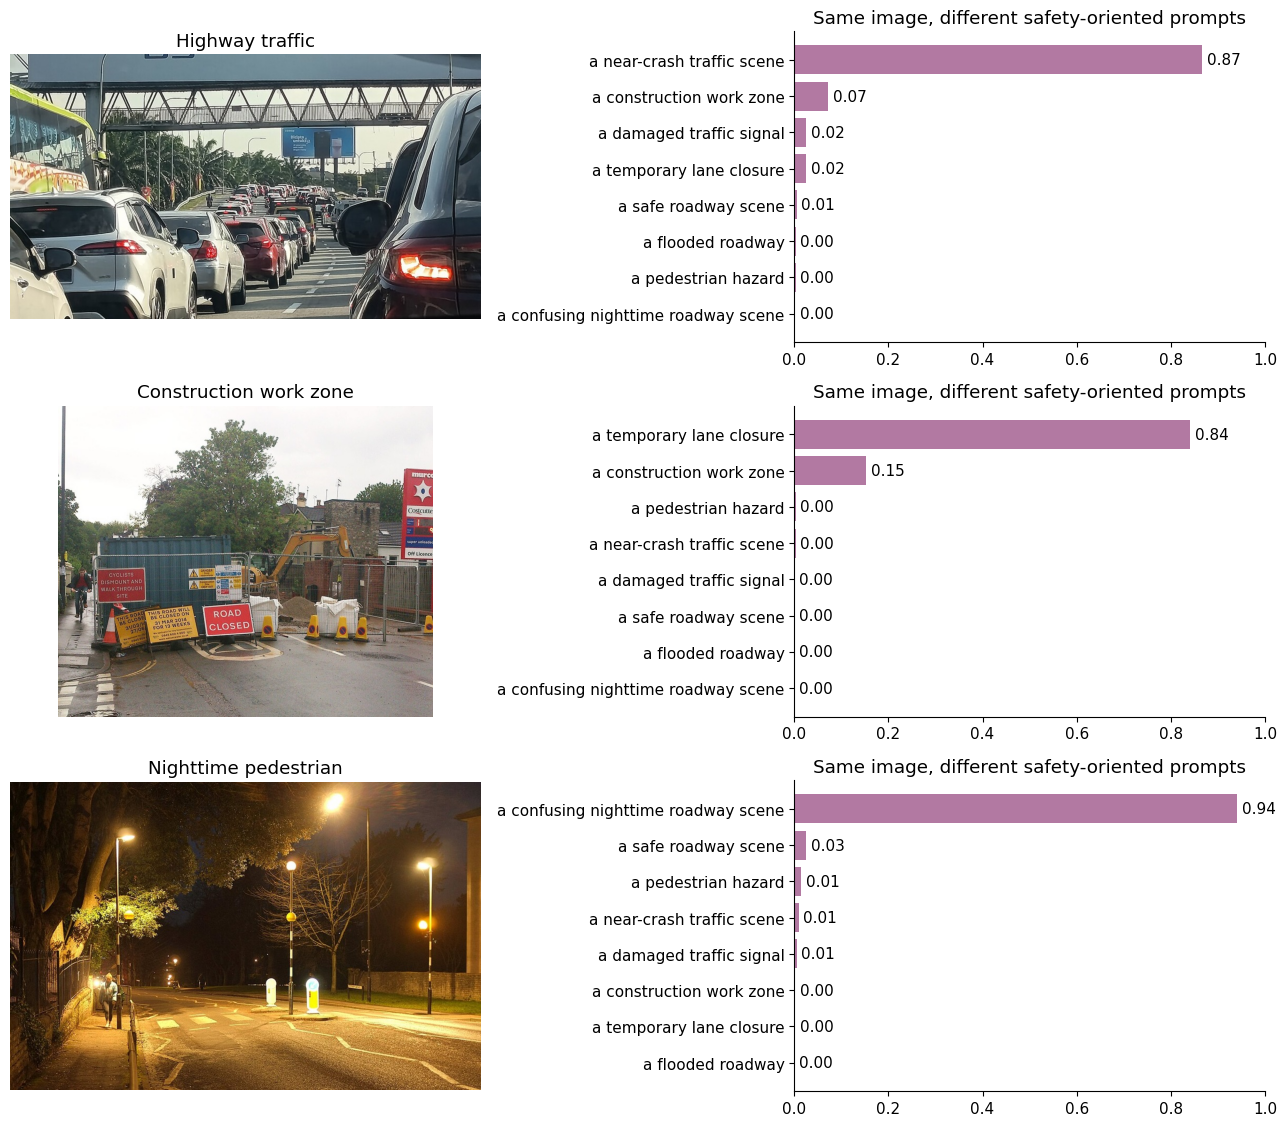

In [29]:
# Prompt sensitivity / failure-case demo
failure_prompts = [
    "a construction work zone",
    "a temporary lane closure",
    "a confusing nighttime roadway scene",
    "a pedestrian hazard",
    "a near-crash traffic scene",
    "a safe roadway scene",
    "a flooded roadway",
    "a damaged traffic signal",
]

# Use a few images likely to reveal ambiguity.
candidate_titles = {"Construction work zone", "Nighttime pedestrian", "Highway traffic"}
failure_items = [item for item in images if item["title"] in candidate_titles]
if not failure_items:
    failure_items = images[:3]

failure_probs, _ = clip_probabilities([item["image"] for item in failure_items], failure_prompts)

fig, axes = plt.subplots(len(failure_items), 2, figsize=(13, 3.8 * len(failure_items)))
if len(failure_items) == 1:
    axes = np.array([axes])
for row, item in enumerate(failure_items):
    ax_img, ax_bar = axes[row]
    ax_img.imshow(item["image"])
    ax_img.set_title(item["title"])
    ax_img.axis("off")

    order = failure_probs[row].argsort()[::-1]
    labels = [failure_prompts[i] for i in order][::-1]
    scores = [failure_probs[row, i] for i in order][::-1]
    ax_bar.barh(labels, scores, color="#B279A2")
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title("Same image, different safety-oriented prompts")
    for y, score in enumerate(scores):
        ax_bar.text(score + 0.01, y, f"{score:.2f}", va="center")
plt.tight_layout()
plt.show()

### Discussion prompt for class

Ask students:

1. Which CLIP matches seem reasonable?
2. Which matches feel misleading?
3. How would you validate a CLIP-based roadway hazard detector before using it in a real transportation system?
4. What additional signals might help: map context, vehicle speed, LiDAR, radar, weather, time of day, or crash records?

## Section 8 — Mobility AI Implications

CLIP-style models are important because transportation environments are **open-world**. The road network contains rare events, temporary conditions, unusual users, and edge cases that are hard to enumerate in advance.

Potential mobility AI applications include:

- **Open-vocabulary roadway hazard detection:** Search dashcam images for "flooded road," "fallen tree," "blocked lane," or "debris in shoulder."
- **Semantic traffic scene understanding:** Summarize what is happening in a complex urban scene using natural language concepts.
- **Intelligent dashcam systems:** Retrieve safety-relevant clips from large video archives using text queries.
- **Post-disaster damage assessment:** Rapidly scan roadway images for washed-out roads, standing water, damaged signals, or blocked access.
- **VLM-assisted ADAS:** Use language-aligned perception to help identify long-tail edge cases that fixed classifiers miss.
- **Infrastructure monitoring:** Query images for pavement distress, missing signs, faded crosswalks, or construction-zone issues.
- **Autonomous driving edge cases:** Explore rare scenarios that may not appear frequently enough for conventional supervised training.

The key idea for AI mobility technologies:

> Language gives transportation researchers a flexible interface to visual data.

That flexibility does not remove the need for careful engineering, evaluation, and safety analysis. But it changes what is possible: instead of defining every class in advance, we can start asking richer questions about the road environment.

In [30]:
# Optional: compact summary table of traditional vs. CLIP-style approaches
import pandas as pd

summary = pd.DataFrame({
    "Dimension": [
        "Output space",
        "New mobility concept",
        "Example query",
        "Strength",
        "Weakness",
    ],
    "Traditional classifier": [
        "Fixed label set",
        "Usually requires new data and retraining",
        "Choose one ImageNet class",
        "Reliable when labels match training task",
        "Limited semantic flexibility",
    ],
    "CLIP-style model": [
        "Natural-language prompt space",
        "Can be queried zero-shot",
        "'a flooded roadway after a storm'",
        "Open-vocabulary semantic search and classification",
        "Prompt-sensitive; not true causal reasoning",
    ],
})
summary

,Dimension,Traditional classifier,CLIP-style model
0,Output space,Fixed label set,Natural-language prompt space
1,New mobility concept,Usually requires new data and retraining,Can be queried zero-shot
2,Example query,Choose one ImageNet class,'a flooded roadway after a storm'
3,Strength,Reliable when labels match training task,Open-vocabulary semantic search and classifica...
4,Weakness,Limited semantic flexibility,Prompt-sensitive; not true causal reasoning
